# Firecracker RL — Offline Training

Trains 6 models on collected EffiBench transitions:
- **Baselines**: Always-Max, Always-Min, Random, Rule-Based
- **Supervised**: Behavioral Cloning (MLP)
- **Offline RL (discrete)**: CQL

Dataset: 278 problems × 14 resource configs = 3892 transitions

In [1]:
!pip install -q torch scikit-learn matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incom

In [2]:
import torch.nn.functional as F

In [3]:
import json, math, random, os
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
print('Imports OK')

Imports OK


## 1. Load Data

Upload  to Kaggle/Colab then set the path below.

In [4]:
TRANS_PATH = '/kaggle/input/datasets/madihaahmedchowdhury/thesis-madiha-ahmed-chowdhury/effibench_transitions.jsonl'
# If running on Colab:
# TRANS_PATH = '/content/drive/MyDrive/firecracker-rl/effibench_transitions.jsonl'

raw = []
with open(TRANS_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            raw.append(json.loads(line))

print(f'Loaded {len(raw)} transitions from {len(set(t["task_id"] for t in raw))} problems')

Loaded 7448 transitions from 532 problems


In [5]:
# ── Action configs (14 discrete resource allocations) ──────────────────────────
ACTION_CONFIGS = [
    {'cpu_millicores':  50, 'memory_limit_mb':  32, 'timeout_ms':  1000},
    {'cpu_millicores':  50, 'memory_limit_mb':  48, 'timeout_ms':  2000},
    {'cpu_millicores':  50, 'memory_limit_mb':  64, 'timeout_ms':  3000},
    {'cpu_millicores':  80, 'memory_limit_mb':  48, 'timeout_ms':  1500},
    {'cpu_millicores':  80, 'memory_limit_mb':  64, 'timeout_ms':  2500},
    {'cpu_millicores':  80, 'memory_limit_mb':  96, 'timeout_ms':  4000},
    {'cpu_millicores': 100, 'memory_limit_mb':  64, 'timeout_ms':  2000},
    {'cpu_millicores': 100, 'memory_limit_mb':  96, 'timeout_ms':  3500},
    {'cpu_millicores': 100, 'memory_limit_mb': 128, 'timeout_ms':  5000},
    {'cpu_millicores': 150, 'memory_limit_mb':  64, 'timeout_ms':  3000},
    {'cpu_millicores': 150, 'memory_limit_mb':  96, 'timeout_ms':  5000},
    {'cpu_millicores': 250, 'memory_limit_mb': 128, 'timeout_ms':  5000},
    {'cpu_millicores': 250, 'memory_limit_mb': 192, 'timeout_ms':  8000},
    {'cpu_millicores': 500, 'memory_limit_mb': 256, 'timeout_ms': 10000},
]
N_ACTIONS = len(ACTION_CONFIGS)
CPU_MAX, MEM_MAX, TO_MAX = 500, 256, 10000

def action_to_idx(action):
    key = (action['cpu_millicores'], action['memory_limit_mb'], action['timeout_ms'])
    for i, c in enumerate(ACTION_CONFIGS):
        if (c['cpu_millicores'], c['memory_limit_mb'], c['timeout_ms']) == key:
            return i
    return -1

# ── All 19 state features ───────────────────────────────────────────────────────
FEATURE_COLS = [
    'prompt_token_count',
    'prompt_complexity_score',
    'task_type',
    'has_loops_hint',
    'has_io_hint',
    'example_count',
    'line_count',
    'cyclomatic_complexity',
    'ast_node_count',
    'has_recursion',
    'has_external_calls',
    'max_loop_depth',
    'estimated_complexity',
    'host_cpu_load_1m',
    'host_mem_available_mb',
    'queue_depth',
    'recent_success_rate',
    'recent_mean_cpu_used',
    'recent_mean_mem_used',
]
N_FEATURES = len(FEATURE_COLS)
print(f'{N_ACTIONS} action configs | {N_FEATURES} state features')

14 action configs | 19 state features


In [6]:
# ── Reward recomputation (matches actions.py exactly) ─────────────────────────
def recompute_reward(t):
    ex     = t['execution']
    action = t['action']

    r_success = 1.0 if ex['exit_code'] == 0 else -2.0
    r_timeout = -5.0 if ex['timed_out'] else 0.0

    wall_ms  = max(ex.get('wall_time_ms', 0) or 0, 1)
    wall_sec = wall_ms / 1000

    cpu_budget_ms = (action['cpu_millicores'] / 1000) * wall_sec * 1000
    cpu_used_ms   = (ex.get('cpu_user_ms', 0) or 0) + (ex.get('cpu_sys_ms', 0) or 0)
    cpu_waste     = max(0.0, (cpu_budget_ms - cpu_used_ms) / max(cpu_budget_ms, 1))

    mem_alloc_kb  = action['memory_limit_mb'] * 1024
    mem_used_kb   = ex.get('mem_peak_kb', 0) or 0
    mem_waste     = max(0.0, (mem_alloc_kb - mem_used_kb) / max(mem_alloc_kb, 1))

    r_resource    = -0.75 * cpu_waste - 0.75 * mem_waste
    r_latency     = -0.2 * math.log(wall_ms / 500 + 1)
    tests_passed  = ex.get('tests_passed')
    r_correctness = 1.0 if tests_passed is True else (-1.0 if tests_passed is False else 0.0)

    return r_success + r_timeout + r_resource + r_latency + r_correctness

# ── Build DataFrame ────────────────────────────────────────────────────────────
rows = []
for t in raw:
    state = t['state']
    row = {
        'task_id':         t['task_id'],
        'action_idx':      action_to_idx(t['action']),
        'reward':          recompute_reward(t),
        'tests_passed':    t['execution']['tests_passed'],
        'exit_code':       t['execution']['exit_code'],
        'timed_out':       t['execution']['timed_out'],
        'cpu_millicores':  t['action']['cpu_millicores'],
        'memory_limit_mb': t['action']['memory_limit_mb'],
        'timeout_ms':      t['action']['timeout_ms'],
        'wall_time_ms':    t['execution'].get('wall_time_ms', 0) or 0,
        'mem_peak_kb':     t['execution'].get('mem_peak_kb', 0) or 0,
        'stress_level':    t.get('meta', {}).get('stress_level', 'unknown'),
    }
    for f in FEATURE_COLS:
        row[f] = float(state.get(f, 0) or 0)
    rows.append(row)

df = pd.DataFrame(rows)
print(f'DataFrame: {df.shape}')
print(df[FEATURE_COLS].describe().round(2))

DataFrame: (7448, 31)
       prompt_token_count  prompt_complexity_score  task_type  has_loops_hint  \
count             7448.00                  7448.00     7448.0         7448.00   
mean               594.86                     0.53        3.0            0.05   
std                401.14                     0.09        0.0            0.22   
min                 53.00                     0.11        3.0            0.00   
25%                419.00                     0.47        3.0            0.00   
50%                539.50                     0.54        3.0            0.00   
75%                690.25                     0.60        3.0            0.00   
max               6392.00                     0.86        3.0            1.00   

       has_io_hint  example_count  line_count  cyclomatic_complexity  \
count       7448.0         7448.0     7448.00                7448.00   
mean           1.0            0.0       38.49                   8.37   
std            0.0            0.

## 2. Train / Test Split

Split by **problem** (not by transition) — test set contains unseen problems.
80% train / 20% test.

In [7]:
all_task_ids = df['task_id'].unique()
np.random.seed(42)
test_ids  = set(np.random.choice(all_task_ids, size=int(len(all_task_ids) * 0.2), replace=False))
train_ids = set(all_task_ids) - test_ids

df_train = df[df['task_id'].isin(train_ids)].reset_index(drop=True)
df_test  = df[df['task_id'].isin(test_ids)].reset_index(drop=True)

print(f'Train: {len(train_ids)} problems | {len(df_train)} transitions')
print(f'Test:  {len(test_ids)}  problems | {len(df_test)}  transitions')

# Normalize state features
scaler = StandardScaler()
X_train_all = scaler.fit_transform(df_train[FEATURE_COLS].values)
X_test_all  = scaler.transform(df_test[FEATURE_COLS].values)

def best_action_per_problem(df_sub):
    best = {}
    for tid, g in df_sub.groupby('task_id'):
        best[tid] = int(g.loc[g['reward'].idxmax(), 'action_idx'])
    return best

train_best = best_action_per_problem(df_train)
test_best  = best_action_per_problem(df_test)

prob_train   = df_train.drop_duplicates('task_id').reset_index(drop=True)
prob_test    = df_test.drop_duplicates('task_id').reset_index(drop=True)
X_prob_train = scaler.transform(prob_train[FEATURE_COLS].values)
X_prob_test  = scaler.transform(prob_test[FEATURE_COLS].values)
y_prob_train = np.array([train_best[t] for t in prob_train['task_id']])
y_prob_test  = np.array([test_best[t]  for t in prob_test['task_id']])
print('BC label distribution (train):')
print(pd.Series(y_prob_train).value_counts().sort_index())

Train: 426 problems | 5964 transitions
Test:  106  problems | 1484  transitions
BC label distribution (train):
0       3
3       3
4       1
5       7
6       4
7      25
9      72
10    303
11      5
13      3
Name: count, dtype: int64


## 3. Evaluation Utility

For each model: pick a config per test problem, look up its actual reward from the dataset.

In [8]:
def evaluate_policy(policy_fn, df_eval, label):
    rewards, successes, oracle_matches = [], [], []
    for tid, group in df_eval.groupby('task_id'):
        state_raw  = group.iloc[0][FEATURE_COLS].values.astype(float)
        state_norm = scaler.transform(state_raw.reshape(1, -1))[0]
        pred_idx   = int(policy_fn(state_norm))
        row        = group[group['action_idx'] == pred_idx]
        if row.empty:
            continue
        r = float(row.iloc[0]['reward'])
        s = 1 if row.iloc[0]['tests_passed'] is True else 0
        oracle_idx   = int(group.loc[group['reward'].idxmax(), 'action_idx'])
        oracle_match = 1 if pred_idx == oracle_idx else 0
        rewards.append(r)
        successes.append(s)
        oracle_matches.append(oracle_match)
    return {
        'model':        label,
        'avg_reward':   float(np.mean(rewards)),
        'success_rate': float(np.mean(successes)),
        'oracle_acc':   float(np.mean(oracle_matches)),
        'n_problems':   len(rewards),
    }

print('Evaluation utility ready.')

Evaluation utility ready.


## 4. Baselines

In [9]:
always_max_fn = lambda s: 13
always_min_fn = lambda s: 0
random_fn     = lambda s: random.randint(0, N_ACTIONS - 1)

def rule_based_fn(s):
    orig = dict(zip(FEATURE_COLS, scaler.inverse_transform(s.reshape(1, -1))[0]))
    cc   = orig['cyclomatic_complexity']
    lc   = orig['line_count']
    ld   = orig['max_loop_depth']
    ec   = orig['estimated_complexity']
    if cc > 15 or ec >= 3 or ld >= 4:
        return 11
    elif cc > 8 or lc > 50:
        return 10
    elif cc > 4 or lc > 20:
        return 7
    else:
        return 5

for name, fn in [('Always-Max', always_max_fn), ('Always-Min', always_min_fn),
                 ('Random', random_fn), ('Rule-Based', rule_based_fn)]:
    r = evaluate_policy(fn, df_test, name)
    print(f"{name:<12} | reward={r['avg_reward']:+.3f} | success={r['success_rate']:.1%} | oracle_acc={r['oracle_acc']:.1%}")

Always-Max   | reward=+0.154 | success=57.5% | oracle_acc=1.9%
Always-Min   | reward=-7.831 | success=0.0% | oracle_acc=0.9%
Random       | reward=-1.765 | success=44.3% | oracle_acc=10.4%
Rule-Based   | reward=+0.018 | success=55.7% | oracle_acc=13.2%


## 5. Behavioral Cloning (BC)

Supervised: learn to predict the best config from state features.
Label = argmax(reward) across 14 transitions per problem.

In [10]:
bc_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=500,
    random_state=42,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
)
bc_model.fit(X_prob_train, y_prob_train)

train_acc = accuracy_score(y_prob_train, bc_model.predict(X_prob_train))
test_acc  = accuracy_score(y_prob_test,  bc_model.predict(X_prob_test))
print(f'BC train accuracy: {train_acc:.3f}')
print(f'BC test  accuracy: {test_acc:.3f}')

bc_policy_fn = lambda s: int(bc_model.predict(s.reshape(1, -1))[0])
r = evaluate_policy(bc_policy_fn, df_test, 'BC')
print(f'BC | reward={r['avg_reward']:+.3f} | success={r['success_rate']:.1%} | oracle_acc={r['oracle_acc']:.1%}')

BC train accuracy: 0.702
BC test  accuracy: 0.717
BC | reward=+0.211 | success=57.5% | oracle_acc=71.7%


## 6. CQL — Conservative Q-Learning (Discrete)

Offline RL: Q-network over 14 discrete actions.
Single-step MDP (done=True always) → target = r (no bootstrapping).
CQL penalty prevents overestimating unseen actions.

In [11]:
# ── Device setup ──────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Network definitions ───────────────────────────────────────────────────────

class QNetwork(nn.Module):
    """Standard Q-network with dropout for regularisation."""
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, n_actions),
        )
    def forward(self, x):
        return self.net(x)


class DuelingQNetwork(nn.Module):
    """Dueling Q-network — separates state value from action advantage."""
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Linear(256, 256),       nn.ReLU(),
        )
        self.value = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )
        self.advantage = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, n_actions),
        )
    def forward(self, x):
        feat = self.feature(x)
        v    = self.value(feat)
        a    = self.advantage(feat)
        return v + (a - a.mean(dim=1, keepdim=True))


# ── Data prep ─────────────────────────────────────────────────────────────────

X_cql = scaler.transform(df_train[FEATURE_COLS].values)
a_cql = df_train['action_idx'].values.astype(int)
r_cql = df_train['reward'].values.astype(np.float32)

# move tensors to GPU if available
Xt = torch.FloatTensor(X_cql).to(device)
at = torch.LongTensor(a_cql).to(device)
rt = torch.FloatTensor(r_cql).to(device)

# ── Hyperparameters ───────────────────────────────────────────────────────────

CQL_ALPHAS  = [0.1, 1.0, 5.0]
N_EPOCHS    = 300
BATCH_SIZE  = 512
LR          = 3e-4

loader = DataLoader(
    TensorDataset(Xt, at, rt),
    batch_size=BATCH_SIZE,
    shuffle=True
)


# ── Training function ─────────────────────────────────────────────────────────

def train_cql(net, alpha, label):
    net = net.to(device)
    opt = optim.Adam(net.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=40
    )
    best_loss  = float('inf')
    no_improve = 0

    for epoch in range(N_EPOCHS):
        net.train()
        total_loss = 0
        for xb, ab, rb in loader:
            # data is already on device from DataLoader
            q_all   = net(xb)
            q_taken = q_all.gather(1, ab.unsqueeze(1)).squeeze(1)

            # Bellman loss — predict reward accurately
            bellman = F.smooth_l1_loss(q_taken, rb)

            # CQL penalty — push down Q-values for
            # actions not seen in the dataset
            cql_pen = (torch.logsumexp(q_all, dim=1)
                       - q_taken).mean()

            loss = bellman + alpha * cql_pen
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        scheduler.step(avg_loss)

        # early stopping
        if avg_loss < best_loss - 1e-4:
            best_loss  = avg_loss
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= 40:
                print(f'  [{label}] early stop at epoch {epoch+1} '
                      f'| best_loss={best_loss:.4f}')
                break

        if (epoch + 1) % 50 == 0:
            print(f'  [{label}] epoch {epoch+1}/{N_EPOCHS} '
                  f'| loss={avg_loss:.4f} '
                  f'| lr={opt.param_groups[0]["lr"]:.2e}')

    net.eval()
    return net


# ── Alpha sweep on standard QNetwork ─────────────────────────────────────────

best_cql_reward = -999
best_cql_net    = None
best_cql_alpha  = None
cql_results     = []

for alpha in CQL_ALPHAS:
    print(f'\nTraining CQL alpha={alpha}...')
    net    = QNetwork(N_FEATURES, N_ACTIONS)
    net    = train_cql(net, alpha, f'CQL α={alpha}')

    def _policy(s, _net=net):
        with torch.no_grad():
            t = torch.FloatTensor(s).unsqueeze(0).to(device)
            return int(_net(t).argmax().item())

    result = evaluate_policy(_policy, df_test, f'CQL_alpha={alpha}')
    cql_results.append({"alpha": alpha, "net": net, "result": result})

    print(f'  → reward={result["avg_reward"]:+.3f} '
          f'| success={result["success_rate"]:.1%} '
          f'| oracle={result["oracle_acc"]:.1%}')

    if result["avg_reward"] > best_cql_reward:
        best_cql_reward = result["avg_reward"]
        best_cql_net    = net
        best_cql_alpha  = alpha

print(f'\nBest standard CQL: alpha={best_cql_alpha} '
      f'reward={best_cql_reward:+.3f}')


# ── Dueling CQL with best alpha ───────────────────────────────────────────────

print(f'\nTraining Dueling CQL (alpha={best_cql_alpha})...')
dueling_net = DuelingQNetwork(N_FEATURES, N_ACTIONS)
dueling_net = train_cql(dueling_net, best_cql_alpha, 'CQL Dueling')

def dueling_cql_policy_fn(s):
    with torch.no_grad():
        t = torch.FloatTensor(s).unsqueeze(0).to(device)
        q = dueling_net(t)
    return int(q.argmax().item())

r_dueling = evaluate_policy(dueling_cql_policy_fn, df_test, 'CQL_Dueling')


# ── Results ───────────────────────────────────────────────────────────────────

print('\n' + '='*56)
print(f"{'Model':<22} {'Reward':>9} {'Success':>9} {'Oracle':>9}")
print('-'*56)
for cr in cql_results:
    r = cr['result']
    print(f"CQL  alpha={cr['alpha']:<8}  "
          f"{r['avg_reward']:>+9.3f} "
          f"{r['success_rate']:>9.1%} "
          f"{r['oracle_acc']:>9.1%}")
print(f"{'CQL  Dueling':<22} "
      f"{r_dueling['avg_reward']:>+9.3f} "
      f"{r_dueling['success_rate']:>9.1%} "
      f"{r_dueling['oracle_acc']:>9.1%}")
print('='*56)


# ── Set best CQL net for downstream use ──────────────────────────────────────

if r_dueling['avg_reward'] > best_cql_reward:
    cql_net       = dueling_net
    cql_policy_fn = dueling_cql_policy_fn
    print(f'\nUsing Dueling CQL as final model '
          f'(reward={r_dueling["avg_reward"]:+.3f})')
else:
    cql_net = best_cql_net
    def cql_policy_fn(s):
        with torch.no_grad():
            t = torch.FloatTensor(s).unsqueeze(0).to(device)
            q = cql_net(t)
        return int(q.argmax().item())
    print(f'\nUsing standard CQL alpha={best_cql_alpha} '
          f'as final model (reward={best_cql_reward:+.3f})')

Using device: cuda
GPU: Tesla T4

Training CQL alpha=0.1...
  [CQL α=0.1] epoch 50/300 | loss=1.3483 | lr=3.00e-04
  [CQL α=0.1] epoch 100/300 | loss=1.2636 | lr=3.00e-04
  [CQL α=0.1] epoch 150/300 | loss=1.2105 | lr=3.00e-04
  [CQL α=0.1] epoch 200/300 | loss=1.1697 | lr=3.00e-04
  [CQL α=0.1] epoch 250/300 | loss=1.1416 | lr=3.00e-04
  [CQL α=0.1] epoch 300/300 | loss=1.1030 | lr=3.00e-04
  → reward=+0.186 | success=57.5% | oracle=8.5%

Training CQL alpha=1.0...
  [CQL α=1.0] epoch 50/300 | loss=4.4693 | lr=3.00e-04
  [CQL α=1.0] epoch 100/300 | loss=4.4048 | lr=3.00e-04
  [CQL α=1.0] epoch 150/300 | loss=4.3425 | lr=3.00e-04
  [CQL α=1.0] epoch 200/300 | loss=4.3000 | lr=3.00e-04
  [CQL α=1.0] epoch 250/300 | loss=4.2602 | lr=3.00e-04
  [CQL α=1.0] epoch 300/300 | loss=4.2065 | lr=3.00e-04
  → reward=+0.095 | success=56.6% | oracle=24.5%

Training CQL alpha=5.0...
  [CQL α=5.0] epoch 50/300 | loss=15.2724 | lr=3.00e-04
  [CQL α=5.0] epoch 100/300 | loss=15.2050 | lr=3.00e-04
  [CQL

CQL with learning rate decay, more epoch and more wide range of alpha

In [12]:
# ── Device setup ──────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Network definitions ───────────────────────────────────────────────────────

class QNetwork(nn.Module):
    """Standard Q-network with dropout for regularisation."""
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, n_actions),
        )
    def forward(self, x):
        return self.net(x)


class DuelingQNetwork(nn.Module):
    """Dueling Q-network — separates state value from action advantage."""
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Linear(256, 256),       nn.ReLU(),
        )
        self.value = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )
        self.advantage = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, n_actions),
        )
    def forward(self, x):
        feat = self.feature(x)
        v    = self.value(feat)
        a    = self.advantage(feat)
        return v + (a - a.mean(dim=1, keepdim=True))


# ── Data prep ─────────────────────────────────────────────────────────────────

X_cql = scaler.transform(df_train[FEATURE_COLS].values)
a_cql = df_train['action_idx'].values.astype(int)
r_cql = df_train['reward'].values.astype(np.float32)

Xt = torch.FloatTensor(X_cql).to(device)
at = torch.LongTensor(a_cql).to(device)
rt = torch.FloatTensor(r_cql).to(device)

# ── Reward normalisation ──────────────────────────────────────────────────────
# rewards range from -7.8 to +1.4 which makes gradients unstable
# normalise to mean=0 std=1 so all reward signals have equal weight

rt_mean = rt.mean()
rt_std  = rt.std() + 1e-8
rt_norm = (rt - rt_mean) / rt_std

print(f"Reward stats  : mean={rt_mean:.3f}  std={rt_std:.3f}")
print(f"Normalised    : min={rt_norm.min():.2f}  max={rt_norm.max():.2f}")

# ── Hyperparameters ───────────────────────────────────────────────────────────

# alpha=0.1 and alpha=5.0 both won last time — explore both ends more
CQL_ALPHAS  = [0.05, 0.1, 5.0, 10.0]
N_EPOCHS    = 600      # was 300 — loss was still dropping at epoch 300
BATCH_SIZE  = 512
LR          = 3e-4

loader = DataLoader(
    TensorDataset(Xt, at, rt_norm),   # normalised rewards
    batch_size=BATCH_SIZE,
    shuffle=True
)

# ── Training function ─────────────────────────────────────────────────────────

def train_cql(net, alpha, label):
    net = net.to(device)

    # weight_decay=1e-5 adds L2 regularisation — prevents overfitting
    opt = optim.Adam(net.parameters(), lr=LR, weight_decay=1e-5)

    # cosine annealing decays lr smoothly from 3e-4 down to 1e-5
    # this is better than ReduceLROnPlateau when loss drops consistently
    # because it does not wait for a plateau that never comes
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=N_EPOCHS, eta_min=1e-5
    )

    best_loss  = float('inf')
    no_improve = 0
    best_state = None   # save best weights, not just final weights

    for epoch in range(N_EPOCHS):
        net.train()
        total_loss = 0

        for xb, ab, rb in loader:
            q_all   = net(xb)
            q_taken = q_all.gather(1, ab.unsqueeze(1)).squeeze(1)

            # Huber loss — less sensitive to extreme reward outliers
            # than MSE, handles the -7.8 timeout transitions better
            bellman = F.smooth_l1_loss(q_taken, rb)

            # CQL penalty — push down Q-values for actions
            # not seen in the dataset, preventing overestimation
            cql_pen = (torch.logsumexp(q_all, dim=1)
                       - q_taken).mean()

            loss = bellman + alpha * cql_pen
            opt.zero_grad()
            loss.backward()

            # clip gradients so one bad batch cannot derail training
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader)

        # cosine scheduler steps every epoch, not on plateau
        scheduler.step()

        # save best weights so we return the best model, not the final one
        if avg_loss < best_loss - 1e-4:
            best_loss  = avg_loss
            no_improve = 0
            best_state = {k: v.clone()
                          for k, v in net.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= 60:
                print(f'  [{label}] early stop at epoch {epoch+1} '
                      f'| best_loss={best_loss:.4f}')
                break

        if (epoch + 1) % 100 == 0:
            print(f'  [{label}] epoch {epoch+1}/{N_EPOCHS} '
                  f'| loss={avg_loss:.4f} '
                  f'| lr={opt.param_groups[0]["lr"]:.2e}')

    # restore best weights before returning
    if best_state is not None:
        net.load_state_dict(best_state)

    net.eval()
    return net


# ── Alpha sweep on standard QNetwork ─────────────────────────────────────────

best_cql_reward = -999
best_cql_net    = None
best_cql_alpha  = None
cql_results     = []

for alpha in CQL_ALPHAS:
    print(f'\nTraining CQL alpha={alpha}...')
    net = QNetwork(N_FEATURES, N_ACTIONS)
    net = train_cql(net, alpha, f'CQL α={alpha}')

    def _policy(s, _net=net):
        with torch.no_grad():
            t = torch.FloatTensor(s).unsqueeze(0).to(device)
            return int(_net(t).argmax().item())

    result = evaluate_policy(_policy, df_test, f'CQL_alpha={alpha}')
    cql_results.append({"alpha": alpha, "net": net, "result": result})

    print(f'  → reward={result["avg_reward"]:+.3f} '
          f'| success={result["success_rate"]:.1%} '
          f'| oracle={result["oracle_acc"]:.1%}')

    if result["avg_reward"] > best_cql_reward:
        best_cql_reward = result["avg_reward"]
        best_cql_net    = net
        best_cql_alpha  = alpha

print(f'\nBest standard CQL: alpha={best_cql_alpha} '
      f'reward={best_cql_reward:+.3f}')


# ── Dueling CQL with best alpha ───────────────────────────────────────────────

print(f'\nTraining Dueling CQL (alpha={best_cql_alpha})...')
dueling_net = DuelingQNetwork(N_FEATURES, N_ACTIONS)
dueling_net = train_cql(dueling_net, best_cql_alpha, 'CQL Dueling')

def dueling_cql_policy_fn(s):
    with torch.no_grad():
        t = torch.FloatTensor(s).unsqueeze(0).to(device)
        q = dueling_net(t)
    return int(q.argmax().item())

r_dueling = evaluate_policy(dueling_cql_policy_fn, df_test, 'CQL_Dueling')


# ── Ensemble CQL with best alpha ──────────────────────────────────────────────
# train 3 networks with different seeds, take minimum Q at inference
# pessimistic ensembling — conservative by design, suits offline RL

print(f'\nTraining Ensemble CQL (alpha={best_cql_alpha}, 3 seeds)...')
ensemble_nets = []

for seed in [42, 123, 777]:
    torch.manual_seed(seed)
    enet = QNetwork(N_FEATURES, N_ACTIONS)
    enet = train_cql(enet, best_cql_alpha, f'CQL ensemble seed={seed}')
    ensemble_nets.append(enet)

def ensemble_cql_policy_fn(s):
    t = torch.FloatTensor(s).unsqueeze(0).to(device)
    with torch.no_grad():
        # take minimum Q across ensemble — pessimistic, avoids OOD overestimation
        q_stack = torch.stack([net(t) for net in ensemble_nets])
        q_min   = q_stack.min(dim=0).values
    return int(q_min.argmax().item())

r_ensemble = evaluate_policy(ensemble_cql_policy_fn, df_test, 'CQL_Ensemble')


# ── Results ───────────────────────────────────────────────────────────────────

print('\n' + '='*58)
print(f"{'Model':<24} {'Reward':>9} {'Success':>9} {'Oracle':>9}")
print('-'*58)
for cr in cql_results:
    r = cr['result']
    print(f"CQL  alpha={cr['alpha']:<10} "
          f"{r['avg_reward']:>+9.3f} "
          f"{r['success_rate']:>9.1%} "
          f"{r['oracle_acc']:>9.1%}")
print(f"{'CQL  Dueling':<24} "
      f"{r_dueling['avg_reward']:>+9.3f} "
      f"{r_dueling['success_rate']:>9.1%} "
      f"{r_dueling['oracle_acc']:>9.1%}")
print(f"{'CQL  Ensemble (min)':<24} "
      f"{r_ensemble['avg_reward']:>+9.3f} "
      f"{r_ensemble['success_rate']:>9.1%} "
      f"{r_ensemble['oracle_acc']:>9.1%}")
print('='*58)


# ── Set best CQL net for downstream use ──────────────────────────────────────

all_variants = [
    (r_ensemble['avg_reward'], 'Ensemble',  ensemble_cql_policy_fn, None),
    (r_dueling['avg_reward'],  'Dueling',   dueling_cql_policy_fn,  dueling_net),
    (best_cql_reward,          f'α={best_cql_alpha}', None, best_cql_net),
]

best_variant = max(all_variants, key=lambda x: x[0])
best_reward, best_name, best_fn, best_net_ref = best_variant

if best_fn is not None:
    cql_policy_fn = best_fn
else:
    # standard net — build policy fn
    _bnet = best_net_ref
    def cql_policy_fn(s):
        with torch.no_grad():
            t = torch.FloatTensor(s).unsqueeze(0).to(device)
            q = _bnet(t)
        return int(q.argmax().item())

cql_net = best_net_ref if best_net_ref is not None else ensemble_nets[0]
print(f'\nBest CQL variant: {best_name} '
      f'(reward={best_reward:+.3f})')

Using device: cuda
GPU: Tesla T4
Reward stats  : mean=-1.402  std=3.482
Normalised    : min=-2.05  max=0.80

Training CQL alpha=0.05...
  [CQL α=0.05] epoch 100/600 | loss=0.2686 | lr=2.81e-04
  [CQL α=0.05] epoch 200/600 | loss=0.2457 | lr=2.28e-04
  [CQL α=0.05] epoch 300/600 | loss=0.2320 | lr=1.55e-04
  [CQL α=0.05] epoch 400/600 | loss=0.2278 | lr=8.25e-05
  [CQL α=0.05] epoch 500/600 | loss=0.2226 | lr=2.94e-05
  [CQL α=0.05] early stop at epoch 556 | best_loss=0.2207
  → reward=-0.062 | success=55.7% | oracle=25.5%

Training CQL alpha=0.1...
  [CQL α=0.1] epoch 100/600 | loss=0.4105 | lr=2.81e-04
  [CQL α=0.1] epoch 200/600 | loss=0.3876 | lr=2.28e-04
  [CQL α=0.1] epoch 300/600 | loss=0.3746 | lr=1.55e-04
  [CQL α=0.1] epoch 400/600 | loss=0.3669 | lr=8.25e-05
  [CQL α=0.1] epoch 500/600 | loss=0.3648 | lr=2.94e-05
  [CQL α=0.1] early stop at epoch 591 | best_loss=0.3622
  → reward=-0.065 | success=55.7% | oracle=21.7%

Training CQL alpha=5.0...
  [CQL α=5.0] epoch 100/600 | lo

# No normalization


In [13]:
# ── Device setup ──────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Network definitions ───────────────────────────────────────────────────────

class QNetwork(nn.Module):
    """Standard Q-network with dropout for regularisation."""
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, n_actions),
        )
    def forward(self, x):
        return self.net(x)


class DuelingQNetwork(nn.Module):
    """Dueling Q-network — separates state value from action advantage."""
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Linear(256, 256),       nn.ReLU(),
        )
        self.value = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )
        self.advantage = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, n_actions),
        )
    def forward(self, x):
        feat = self.feature(x)
        v    = self.value(feat)
        a    = self.advantage(feat)
        return v + (a - a.mean(dim=1, keepdim=True))


# ── Data prep ─────────────────────────────────────────────────────────────────

X_cql = scaler.transform(df_train[FEATURE_COLS].values)
a_cql = df_train['action_idx'].values.astype(int)
r_cql = df_train['reward'].values.astype(np.float32)

Xt = torch.FloatTensor(X_cql).to(device)
at = torch.LongTensor(a_cql).to(device)
rt = torch.FloatTensor(r_cql).to(device)


# ── Hyperparameters ───────────────────────────────────────────────────────────

# alpha=0.1 and alpha=5.0 both won last time — explore both ends more
CQL_ALPHAS  = [0.05, 0.1, 5.0, 10.0]
N_EPOCHS    = 1000      # was 300 — loss was still dropping at epoch 300
BATCH_SIZE  = 512
LR          = 3e-4

loader = DataLoader(
    TensorDataset(Xt, at, rt),   # unnormalised rewards
    batch_size=BATCH_SIZE,
    shuffle=True
)

# ── Training function ─────────────────────────────────────────────────────────

def train_cql(net, alpha, label):
    net = net.to(device)

    # weight_decay=1e-5 adds L2 regularisation — prevents overfitting
    opt = optim.Adam(net.parameters(), lr=LR, weight_decay=1e-5)

    # cosine annealing decays lr smoothly from 3e-4 down to 1e-5
    # this is better than ReduceLROnPlateau when loss drops consistently
    # because it does not wait for a plateau that never comes
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=N_EPOCHS, eta_min=1e-5
    )

    best_loss  = float('inf')
    no_improve = 0
    best_state = None   # save best weights, not just final weights

    for epoch in range(N_EPOCHS):
        net.train()
        total_loss = 0

        for xb, ab, rb in loader:
            q_all   = net(xb)
            q_taken = q_all.gather(1, ab.unsqueeze(1)).squeeze(1)

            # Huber loss — less sensitive to extreme reward outliers
            # than MSE, handles the -7.8 timeout transitions better
            bellman = F.smooth_l1_loss(q_taken, rb)

            # CQL penalty — push down Q-values for actions
            # not seen in the dataset, preventing overestimation
            cql_pen = (torch.logsumexp(q_all, dim=1)
                       - q_taken).mean()

            loss = bellman + alpha * cql_pen
            opt.zero_grad()
            loss.backward()

            # clip gradients so one bad batch cannot derail training
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader)

        # cosine scheduler steps every epoch, not on plateau
        scheduler.step()

        # save best weights so we return the best model, not the final one
        if avg_loss < best_loss - 1e-4:
            best_loss  = avg_loss
            no_improve = 0
            best_state = {k: v.clone()
                          for k, v in net.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= 60:
                print(f'  [{label}] early stop at epoch {epoch+1} '
                      f'| best_loss={best_loss:.4f}')
                break

        if (epoch + 1) % 100 == 0:
            print(f'  [{label}] epoch {epoch+1}/{N_EPOCHS} '
                  f'| loss={avg_loss:.4f} '
                  f'| lr={opt.param_groups[0]["lr"]:.2e}')

    # restore best weights before returning
    if best_state is not None:
        net.load_state_dict(best_state)

    net.eval()
    return net


# ── Alpha sweep on standard QNetwork ─────────────────────────────────────────

best_cql_reward = -999
best_cql_net    = None
best_cql_alpha  = None
cql_results     = []

for alpha in CQL_ALPHAS:
    print(f'\nTraining CQL alpha={alpha}...')
    net = QNetwork(N_FEATURES, N_ACTIONS)
    net = train_cql(net, alpha, f'CQL α={alpha}')

    def _policy(s, _net=net):
        with torch.no_grad():
            t = torch.FloatTensor(s).unsqueeze(0).to(device)
            return int(_net(t).argmax().item())

    result = evaluate_policy(_policy, df_test, f'CQL_alpha={alpha}')
    cql_results.append({"alpha": alpha, "net": net, "result": result})

    print(f'  → reward={result["avg_reward"]:+.3f} '
          f'| success={result["success_rate"]:.1%} '
          f'| oracle={result["oracle_acc"]:.1%}')

    if result["avg_reward"] > best_cql_reward:
        best_cql_reward = result["avg_reward"]
        best_cql_net    = net
        best_cql_alpha  = alpha

print(f'\nBest standard CQL: alpha={best_cql_alpha} '
      f'reward={best_cql_reward:+.3f}')


# ── Dueling CQL with best alpha ───────────────────────────────────────────────

print(f'\nTraining Dueling CQL (alpha={best_cql_alpha})...')
dueling_net = DuelingQNetwork(N_FEATURES, N_ACTIONS)
dueling_net = train_cql(dueling_net, best_cql_alpha, 'CQL Dueling')

def dueling_cql_policy_fn(s):
    with torch.no_grad():
        t = torch.FloatTensor(s).unsqueeze(0).to(device)
        q = dueling_net(t)
    return int(q.argmax().item())

r_dueling = evaluate_policy(dueling_cql_policy_fn, df_test, 'CQL_Dueling')


# ── Ensemble CQL with best alpha ──────────────────────────────────────────────
# train 3 networks with different seeds, take minimum Q at inference
# pessimistic ensembling — conservative by design, suits offline RL

print(f'\nTraining Ensemble CQL (alpha={best_cql_alpha}, 3 seeds)...')
ensemble_nets = []

for seed in [42, 123, 777]:
    torch.manual_seed(seed)
    enet = QNetwork(N_FEATURES, N_ACTIONS)
    enet = train_cql(enet, best_cql_alpha, f'CQL ensemble seed={seed}')
    ensemble_nets.append(enet)

def ensemble_cql_policy_fn(s):
    t = torch.FloatTensor(s).unsqueeze(0).to(device)
    with torch.no_grad():
        # take minimum Q across ensemble — pessimistic, avoids OOD overestimation
        q_stack = torch.stack([net(t) for net in ensemble_nets])
        q_min   = q_stack.min(dim=0).values
    return int(q_min.argmax().item())

r_ensemble = evaluate_policy(ensemble_cql_policy_fn, df_test, 'CQL_Ensemble')


# ── Results ───────────────────────────────────────────────────────────────────

print('\n' + '='*58)
print(f"{'Model':<24} {'Reward':>9} {'Success':>9} {'Oracle':>9}")
print('-'*58)
for cr in cql_results:
    r = cr['result']
    print(f"CQL  alpha={cr['alpha']:<10} "
          f"{r['avg_reward']:>+9.3f} "
          f"{r['success_rate']:>9.1%} "
          f"{r['oracle_acc']:>9.1%}")
print(f"{'CQL  Dueling':<24} "
      f"{r_dueling['avg_reward']:>+9.3f} "
      f"{r_dueling['success_rate']:>9.1%} "
      f"{r_dueling['oracle_acc']:>9.1%}")
print(f"{'CQL  Ensemble (min)':<24} "
      f"{r_ensemble['avg_reward']:>+9.3f} "
      f"{r_ensemble['success_rate']:>9.1%} "
      f"{r_ensemble['oracle_acc']:>9.1%}")
print('='*58)


# ── Set best CQL net for downstream use ──────────────────────────────────────

all_variants = [
    (r_ensemble['avg_reward'], 'Ensemble',  ensemble_cql_policy_fn, None),
    (r_dueling['avg_reward'],  'Dueling',   dueling_cql_policy_fn,  dueling_net),
    (best_cql_reward,          f'α={best_cql_alpha}', None, best_cql_net),
]

best_variant = max(all_variants, key=lambda x: x[0])
best_reward, best_name, best_fn, best_net_ref = best_variant

if best_fn is not None:
    cql_policy_fn = best_fn
else:
    # standard net — build policy fn
    _bnet = best_net_ref
    def cql_policy_fn(s):
        with torch.no_grad():
            t = torch.FloatTensor(s).unsqueeze(0).to(device)
            q = _bnet(t)
        return int(q.argmax().item())

cql_net = best_net_ref if best_net_ref is not None else ensemble_nets[0]
print(f'\nBest CQL variant: {best_name} '
      f'(reward={best_reward:+.3f})')

Using device: cuda
GPU: Tesla T4

Training CQL alpha=0.05...
  [CQL α=0.05] epoch 100/1000 | loss=1.0712 | lr=2.93e-04
  [CQL α=0.05] epoch 200/1000 | loss=0.9665 | lr=2.72e-04
  [CQL α=0.05] epoch 300/1000 | loss=0.9131 | lr=2.40e-04
  [CQL α=0.05] epoch 400/1000 | loss=0.8638 | lr=2.00e-04
  [CQL α=0.05] epoch 500/1000 | loss=0.8238 | lr=1.55e-04
  [CQL α=0.05] epoch 600/1000 | loss=0.7908 | lr=1.10e-04
  [CQL α=0.05] epoch 700/1000 | loss=0.7844 | lr=6.98e-05
  [CQL α=0.05] early stop at epoch 776 | best_loss=0.7678
  → reward=+0.043 | success=56.6% | oracle=50.0%

Training CQL alpha=0.1...
  [CQL α=0.1] epoch 100/1000 | loss=1.2709 | lr=2.93e-04
  [CQL α=0.1] epoch 200/1000 | loss=1.1687 | lr=2.72e-04
  [CQL α=0.1] epoch 300/1000 | loss=1.1065 | lr=2.40e-04
  [CQL α=0.1] epoch 400/1000 | loss=1.0586 | lr=2.00e-04
  [CQL α=0.1] epoch 500/1000 | loss=1.0180 | lr=1.55e-04
  [CQL α=0.1] epoch 600/1000 | loss=0.9903 | lr=1.10e-04
  [CQL α=0.1] epoch 700/1000 | loss=0.9828 | lr=6.98e-05


# Using variants of alpha

In [14]:
# ── Device setup ──────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Network definitions ───────────────────────────────────────────────────────

class QNetwork(nn.Module):
    """Standard Q-network with dropout for regularisation."""
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, n_actions),
        )
    def forward(self, x):
        return self.net(x)


class DuelingQNetwork(nn.Module):
    """Dueling Q-network — separates state value from action advantage."""
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Linear(256, 256),       nn.ReLU(),
        )
        self.value = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )
        self.advantage = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, n_actions),
        )
    def forward(self, x):
        feat = self.feature(x)
        v    = self.value(feat)
        a    = self.advantage(feat)
        return v + (a - a.mean(dim=1, keepdim=True))


# ── Data prep ─────────────────────────────────────────────────────────────────

X_cql = scaler.transform(df_train[FEATURE_COLS].values)
a_cql = df_train['action_idx'].values.astype(int)
r_cql = df_train['reward'].values.astype(np.float32)

Xt = torch.FloatTensor(X_cql).to(device)
at = torch.LongTensor(a_cql).to(device)
rt = torch.FloatTensor(r_cql).to(device)


# ── Hyperparameters ───────────────────────────────────────────────────────────

# alpha=0.1 and alpha=5.0 both won last time — explore both ends more
CQL_ALPHAS  = [0.05, 0.8, 0.1, 0.15, 0.5, 1.0, 3.0, 5.0, 7.5, 10.0]
N_EPOCHS    = 1000      # was 300 — loss was still dropping at epoch 300
BATCH_SIZE  = 512
LR          = 3e-4

loader = DataLoader(
    TensorDataset(Xt, at, rt),   # unnormalised rewards
    batch_size=BATCH_SIZE,
    shuffle=True
)

# ── Training function ─────────────────────────────────────────────────────────

def train_cql(net, alpha, label):
    net = net.to(device)

    # weight_decay=1e-5 adds L2 regularisation — prevents overfitting
    opt = optim.Adam(net.parameters(), lr=LR, weight_decay=1e-5)

    # cosine annealing decays lr smoothly from 3e-4 down to 1e-5
    # this is better than ReduceLROnPlateau when loss drops consistently
    # because it does not wait for a plateau that never comes
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=N_EPOCHS, eta_min=1e-5
    )

    best_loss  = float('inf')
    no_improve = 0
    best_state = None   # save best weights, not just final weights

    for epoch in range(N_EPOCHS):
        net.train()
        total_loss = 0

        for xb, ab, rb in loader:
            q_all   = net(xb)
            q_taken = q_all.gather(1, ab.unsqueeze(1)).squeeze(1)

            # Huber loss — less sensitive to extreme reward outliers
            # than MSE, handles the -7.8 timeout transitions better
            bellman = F.smooth_l1_loss(q_taken, rb)

            # CQL penalty — push down Q-values for actions
            # not seen in the dataset, preventing overestimation
            cql_pen = (torch.logsumexp(q_all, dim=1)
                       - q_taken).mean()

            loss = bellman + alpha * cql_pen
            opt.zero_grad()
            loss.backward()

            # clip gradients so one bad batch cannot derail training
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader)

        # cosine scheduler steps every epoch, not on plateau
        scheduler.step()

        # save best weights so we return the best model, not the final one
        if avg_loss < best_loss - 1e-4:
            best_loss  = avg_loss
            no_improve = 0
            best_state = {k: v.clone()
                          for k, v in net.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= 60:
                print(f'  [{label}] early stop at epoch {epoch+1} '
                      f'| best_loss={best_loss:.4f}')
                break

        if (epoch + 1) % 100 == 0:
            print(f'  [{label}] epoch {epoch+1}/{N_EPOCHS} '
                  f'| loss={avg_loss:.4f} '
                  f'| lr={opt.param_groups[0]["lr"]:.2e}')

    # restore best weights before returning
    if best_state is not None:
        net.load_state_dict(best_state)

    net.eval()
    return net


# ── Alpha sweep on standard QNetwork ─────────────────────────────────────────

best_cql_reward = -999
best_cql_net    = None
best_cql_alpha  = None
cql_results     = []

for alpha in CQL_ALPHAS:
    print(f'\nTraining CQL alpha={alpha}...')
    net = QNetwork(N_FEATURES, N_ACTIONS)
    net = train_cql(net, alpha, f'CQL α={alpha}')

    def _policy(s, _net=net):
        with torch.no_grad():
            t = torch.FloatTensor(s).unsqueeze(0).to(device)
            return int(_net(t).argmax().item())

    result = evaluate_policy(_policy, df_test, f'CQL_alpha={alpha}')
    cql_results.append({"alpha": alpha, "net": net, "result": result})

    print(f'  → reward={result["avg_reward"]:+.3f} '
          f'| success={result["success_rate"]:.1%} '
          f'| oracle={result["oracle_acc"]:.1%}')

    if result["avg_reward"] > best_cql_reward:
        best_cql_reward = result["avg_reward"]
        best_cql_net    = net
        best_cql_alpha  = alpha

print(f'\nBest standard CQL: alpha={best_cql_alpha} '
      f'reward={best_cql_reward:+.3f}')


# ── Dueling CQL with best alpha ───────────────────────────────────────────────

print(f'\nTraining Dueling CQL (alpha={best_cql_alpha})...')
dueling_net = DuelingQNetwork(N_FEATURES, N_ACTIONS)
dueling_net = train_cql(dueling_net, best_cql_alpha, 'CQL Dueling')

def dueling_cql_policy_fn(s):
    with torch.no_grad():
        t = torch.FloatTensor(s).unsqueeze(0).to(device)
        q = dueling_net(t)
    return int(q.argmax().item())

r_dueling = evaluate_policy(dueling_cql_policy_fn, df_test, 'CQL_Dueling')


# ── Ensemble CQL with best alpha ──────────────────────────────────────────────
# train 3 networks with different seeds, take minimum Q at inference
# pessimistic ensembling — conservative by design, suits offline RL

print(f'\nTraining Ensemble CQL (alpha={best_cql_alpha}, 3 seeds)...')
ensemble_nets = []

for seed in [42, 123, 777]:
    torch.manual_seed(seed)
    enet = QNetwork(N_FEATURES, N_ACTIONS)
    enet = train_cql(enet, best_cql_alpha, f'CQL ensemble seed={seed}')
    ensemble_nets.append(enet)

def ensemble_cql_policy_fn(s):
    t = torch.FloatTensor(s).unsqueeze(0).to(device)
    with torch.no_grad():
        # take minimum Q across ensemble — pessimistic, avoids OOD overestimation
        q_stack = torch.stack([net(t) for net in ensemble_nets])
        q_min   = q_stack.min(dim=0).values
    return int(q_min.argmax().item())

r_ensemble = evaluate_policy(ensemble_cql_policy_fn, df_test, 'CQL_Ensemble')


# ── Results ───────────────────────────────────────────────────────────────────

print('\n' + '='*58)
print(f"{'Model':<24} {'Reward':>9} {'Success':>9} {'Oracle':>9}")
print('-'*58)
for cr in cql_results:
    r = cr['result']
    print(f"CQL  alpha={cr['alpha']:<10} "
          f"{r['avg_reward']:>+9.3f} "
          f"{r['success_rate']:>9.1%} "
          f"{r['oracle_acc']:>9.1%}")
print(f"{'CQL  Dueling':<24} "
      f"{r_dueling['avg_reward']:>+9.3f} "
      f"{r_dueling['success_rate']:>9.1%} "
      f"{r_dueling['oracle_acc']:>9.1%}")
print(f"{'CQL  Ensemble (min)':<24} "
      f"{r_ensemble['avg_reward']:>+9.3f} "
      f"{r_ensemble['success_rate']:>9.1%} "
      f"{r_ensemble['oracle_acc']:>9.1%}")
print('='*58)


# ── Set best CQL net for downstream use ──────────────────────────────────────

all_variants = [
    (r_ensemble['avg_reward'], 'Ensemble',  ensemble_cql_policy_fn, None),
    (r_dueling['avg_reward'],  'Dueling',   dueling_cql_policy_fn,  dueling_net),
    (best_cql_reward,          f'α={best_cql_alpha}', None, best_cql_net),
]

best_variant = max(all_variants, key=lambda x: x[0])
best_reward, best_name, best_fn, best_net_ref = best_variant

if best_fn is not None:
    cql_policy_fn = best_fn
else:
    # standard net — build policy fn
    _bnet = best_net_ref
    def cql_policy_fn(s):
        with torch.no_grad():
            t = torch.FloatTensor(s).unsqueeze(0).to(device)
            q = _bnet(t)
        return int(q.argmax().item())

cql_net = best_net_ref if best_net_ref is not None else ensemble_nets[0]
print(f'\nBest CQL variant: {best_name} '
      f'(reward={best_reward:+.3f})')

Using device: cuda
GPU: Tesla T4

Training CQL alpha=0.05...
  [CQL α=0.05] epoch 100/1000 | loss=1.0693 | lr=2.93e-04
  [CQL α=0.05] epoch 200/1000 | loss=0.9778 | lr=2.72e-04
  [CQL α=0.05] epoch 300/1000 | loss=0.9131 | lr=2.40e-04
  [CQL α=0.05] epoch 400/1000 | loss=0.8637 | lr=2.00e-04
  [CQL α=0.05] epoch 500/1000 | loss=0.8337 | lr=1.55e-04
  [CQL α=0.05] epoch 600/1000 | loss=0.8086 | lr=1.10e-04
  [CQL α=0.05] epoch 700/1000 | loss=0.7921 | lr=6.98e-05
  [CQL α=0.05] epoch 800/1000 | loss=0.7768 | lr=3.77e-05
  [CQL α=0.05] epoch 900/1000 | loss=0.7722 | lr=1.71e-05
  [CQL α=0.05] early stop at epoch 930 | best_loss=0.7678
  → reward=+0.018 | success=55.7% | oracle=31.1%

Training CQL alpha=0.8...
  [CQL α=0.8] epoch 100/1000 | loss=3.7841 | lr=2.93e-04
  [CQL α=0.8] epoch 200/1000 | loss=3.6832 | lr=2.72e-04
  [CQL α=0.8] epoch 300/1000 | loss=3.6126 | lr=2.40e-04
  [CQL α=0.8] epoch 400/1000 | loss=3.5538 | lr=2.00e-04
  [CQL α=0.8] epoch 500/1000 | loss=3.5254 | lr=1.55e-0

# USing alpha as 0.1, epoch as 1000 and adding one more layer

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# CQL BEST MODEL — alpha=0.1 (best oracle accuracy)
# Deeper network: 256 → 256 → 128 → n_actions
# Trains: standard, dueling, ensemble all with alpha=0.1
# ══════════════════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# ── Best alpha from sweep ─────────────────────────────────────────────────────

BEST_ALPHA  = 0.1
N_EPOCHS    = 1000
BATCH_SIZE  = 512
LR          = 3e-4

# ── Deeper network definitions ────────────────────────────────────────────────

class QNetworkDeep(nn.Module):
    """
    Deeper Q-network: 256 → 256 → 128 → n_actions
    One extra layer vs previous version.
    Helps alpha=0.1 learn finer distinctions between similar configs.
    Going deeper than this (4+ layers) does not help on 8000 rows.
    """
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),       nn.ReLU(),
            nn.Dropout(0.05),          # lighter dropout on final hidden layer
            nn.Linear(128, n_actions),
        )
    def forward(self, x):
        return self.net(x)


class DuelingQNetworkDeep(nn.Module):
    """
    Deeper dueling network.
    Feature extractor: 256 → 256 → 128
    Value head:  128 → 64 → 1
    Advantage head: 128 → 64 → n_actions
    """
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),       nn.ReLU(),
        )
        self.value = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )
        self.advantage = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, n_actions),
        )
    def forward(self, x):
        feat = self.feature(x)
        v    = self.value(feat)
        a    = self.advantage(feat)
        return v + (a - a.mean(dim=1, keepdim=True))


# ── Data prep ─────────────────────────────────────────────────────────────────

X_best = scaler.transform(df_train[FEATURE_COLS].values)
a_best = df_train['action_idx'].values.astype(int)
r_best = df_train['reward'].values.astype(np.float32)

Xb = torch.FloatTensor(X_best).to(device)
ab = torch.LongTensor(a_best).to(device)
rb = torch.FloatTensor(r_best).to(device)

loader_best = DataLoader(
    TensorDataset(Xb, ab, rb),
    batch_size=BATCH_SIZE,
    shuffle=True
)

# ── Training function ─────────────────────────────────────────────────────────

def train_best_cql(net, label):
    net = net.to(device)
    opt = optim.Adam(net.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=50
    )

    best_loss  = float('inf')
    no_improve = 0
    best_state = None

    for epoch in range(N_EPOCHS):
        net.train()
        total_loss = 0

        for xb_batch, ab_batch, rb_batch in loader_best:
            q_all   = net(xb_batch)
            q_taken = q_all.gather(1, ab_batch.unsqueeze(1)).squeeze(1)

            bellman = F.smooth_l1_loss(q_taken, rb_batch)
            cql_pen = (torch.logsumexp(q_all, dim=1)
                       - q_taken).mean()

            loss = bellman + BEST_ALPHA * cql_pen
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader_best)
        scheduler.step(avg_loss)

        # save best weights
        if avg_loss < best_loss - 1e-4:
            best_loss  = avg_loss
            no_improve = 0
            best_state = {k: v.clone()
                          for k, v in net.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= 80:
                print(f'  [{label}] early stop at epoch {epoch+1} '
                      f'| best_loss={best_loss:.4f}')
                break

        if (epoch + 1) % 100 == 0:
            print(f'  [{label}] epoch {epoch+1}/{N_EPOCHS} '
                  f'| loss={avg_loss:.4f} '
                  f'| lr={opt.param_groups[0]["lr"]:.2e}')

    if best_state is not None:
        net.load_state_dict(best_state)
    net.eval()
    return net


# ── 1. Standard deep CQL ──────────────────────────────────────────────────────

print(f'Training standard CQL (alpha={BEST_ALPHA}, deeper network)...')
cql_best_net = QNetworkDeep(N_FEATURES, N_ACTIONS)
cql_best_net = train_best_cql(cql_best_net, f'CQL α={BEST_ALPHA} deep')

def cql_best_policy_fn(s):
    with torch.no_grad():
        t = torch.FloatTensor(s).unsqueeze(0).to(device)
        return int(cql_best_net(t).argmax().item())

r_best_standard = evaluate_policy(cql_best_policy_fn, df_test, 'CQL_best_standard')
print(f'  → reward={r_best_standard["avg_reward"]:+.3f} '
      f'| success={r_best_standard["success_rate"]:.1%} '
      f'| oracle={r_best_standard["oracle_acc"]:.1%}')


# ── 2. Dueling deep CQL ───────────────────────────────────────────────────────

print(f'\nTraining Dueling CQL (alpha={BEST_ALPHA}, deeper network)...')
cql_dueling_best = DuelingQNetworkDeep(N_FEATURES, N_ACTIONS)
cql_dueling_best = train_best_cql(cql_dueling_best, f'CQL Dueling α={BEST_ALPHA}')

def cql_dueling_best_policy_fn(s):
    with torch.no_grad():
        t = torch.FloatTensor(s).unsqueeze(0).to(device)
        return int(cql_dueling_best(t).argmax().item())

r_best_dueling = evaluate_policy(
    cql_dueling_best_policy_fn, df_test, 'CQL_best_dueling'
)
print(f'  → reward={r_best_dueling["avg_reward"]:+.3f} '
      f'| success={r_best_dueling["success_rate"]:.1%} '
      f'| oracle={r_best_dueling["oracle_acc"]:.1%}')


# ── 3. Ensemble deep CQL ──────────────────────────────────────────────────────

print(f'\nTraining Ensemble CQL (alpha={BEST_ALPHA}, 3 seeds, deeper network)...')
ensemble_best_nets = []

for seed in [42, 123, 777]:
    torch.manual_seed(seed)
    print(f'  seed={seed}...')
    enet = QNetworkDeep(N_FEATURES, N_ACTIONS)
    enet = train_best_cql(enet, f'CQL ensemble seed={seed}')
    ensemble_best_nets.append(enet)

def cql_ensemble_best_policy_fn(s):
    t = torch.FloatTensor(s).unsqueeze(0).to(device)
    with torch.no_grad():
        q_stack = torch.stack([net(t) for net in ensemble_best_nets])
        q_min   = q_stack.min(dim=0).values   # pessimistic — take minimum
    return int(q_min.argmax().item())

r_best_ensemble = evaluate_policy(
    cql_ensemble_best_policy_fn, df_test, 'CQL_best_ensemble'
)
print(f'  → reward={r_best_ensemble["avg_reward"]:+.3f} '
      f'| success={r_best_ensemble["success_rate"]:.1%} '
      f'| oracle={r_best_ensemble["oracle_acc"]:.1%}')


# ── Results ───────────────────────────────────────────────────────────────────

print('\n' + '='*58)
print(f"  All models use alpha={BEST_ALPHA} (best oracle from sweep)")
print('='*58)
print(f"{'Model':<26} {'Reward':>9} {'Success':>9} {'Oracle':>9}")
print('-'*58)
print(f"{'CQL  standard (deep)':<26} "
      f"{r_best_standard['avg_reward']:>+9.3f} "
      f"{r_best_standard['success_rate']:>9.1%} "
      f"{r_best_standard['oracle_acc']:>9.1%}")
print(f"{'CQL  dueling (deep)':<26} "
      f"{r_best_dueling['avg_reward']:>+9.3f} "
      f"{r_best_dueling['success_rate']:>9.1%} "
      f"{r_best_dueling['oracle_acc']:>9.1%}")
print(f"{'CQL  ensemble (deep)':<26} "
      f"{r_best_ensemble['avg_reward']:>+9.3f} "
      f"{r_best_ensemble['success_rate']:>9.1%} "
      f"{r_best_ensemble['oracle_acc']:>9.1%}")
print('='*58)


# ── Set final best model ──────────────────────────────────────────────────────

_candidates = [
    (r_best_standard['avg_reward'], 'standard',
     cql_best_policy_fn,        cql_best_net),
    (r_best_dueling['avg_reward'],  'dueling',
     cql_dueling_best_policy_fn, cql_dueling_best),
    (r_best_ensemble['avg_reward'], 'ensemble',
     cql_ensemble_best_policy_fn, ensemble_best_nets[0]),
]

best_r, best_name, cql_policy_fn, cql_net = max(
    _candidates, key=lambda x: x[0]
)
print(f'\nFinal CQL model: {best_name} '
      f'(reward={best_r:+.3f})')
print('cql_policy_fn and cql_net set for downstream use.')

Training standard CQL (alpha=0.1, deeper network)...
  [CQL α=0.1 deep] epoch 100/1000 | loss=1.2101 | lr=3.00e-04
  [CQL α=0.1 deep] epoch 200/1000 | loss=1.0523 | lr=3.00e-04
  [CQL α=0.1 deep] epoch 300/1000 | loss=0.9327 | lr=3.00e-04
  [CQL α=0.1 deep] epoch 400/1000 | loss=0.8472 | lr=3.00e-04
  [CQL α=0.1 deep] epoch 500/1000 | loss=0.7971 | lr=3.00e-04
  [CQL α=0.1 deep] epoch 600/1000 | loss=0.7545 | lr=3.00e-04
  [CQL α=0.1 deep] epoch 700/1000 | loss=0.7161 | lr=3.00e-04
  [CQL α=0.1 deep] epoch 800/1000 | loss=0.6919 | lr=3.00e-04
  [CQL α=0.1 deep] epoch 900/1000 | loss=0.6634 | lr=3.00e-04
  [CQL α=0.1 deep] epoch 1000/1000 | loss=0.6386 | lr=3.00e-04
  → reward=-0.192 | success=54.7% | oracle=9.4%

Training Dueling CQL (alpha=0.1, deeper network)...
  [CQL Dueling α=0.1] epoch 100/1000 | loss=1.0826 | lr=3.00e-04
  [CQL Dueling α=0.1] epoch 200/1000 | loss=0.9087 | lr=3.00e-04
  [CQL Dueling α=0.1] epoch 300/1000 | loss=0.8040 | lr=3.00e-04
  [CQL Dueling α=0.1] epoch 40

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# CQL FINAL — alpha=0.1, deeper network, cosine LR, AdamW, stratified data
# All fixes applied:
#   - CosineAnnealingLR so lr actually decays
#   - AdamW for better weight decay
#   - best_state saving (returns best weights not final weights)
#   - patience=100 so early stopping is not too aggressive
#   - trains on ALL transitions (not just best-per-problem) with reward signal
# ══════════════════════════════════════════════════════════════════════════════

BEST_ALPHA = 0.1
N_EPOCHS   = 1500
BATCH_SIZE = 512
LR         = 3e-4

# ── Network definitions ───────────────────────────────────────────────────────

class QNetworkDeep(nn.Module):
    """256 → 256 → 128 → n_actions with dropout."""
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),       nn.ReLU(),
            nn.Dropout(0.05),
            nn.Linear(128, n_actions),
        )
    def forward(self, x):
        return self.net(x)


class DuelingQNetworkDeep(nn.Module):
    """Deeper dueling network — separates V(s) from A(s,a)."""
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),       nn.ReLU(),
        )
        self.value = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )
        self.advantage = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, n_actions),
        )
    def forward(self, x):
        feat = self.feature(x)
        v    = self.value(feat)
        a    = self.advantage(feat)
        return v + (a - a.mean(dim=1, keepdim=True))


# ── Data prep — ALL transitions, not just best-per-problem ───────────────────
X_cql_f = scaler.transform(df_train[FEATURE_COLS].values)
a_cql_f = df_train['action_idx'].values.astype(int)
r_cql_f = df_train['reward'].values.astype(np.float32)

Xf = torch.FloatTensor(X_cql_f).to(device)
af = torch.LongTensor(a_cql_f).to(device)
rf = torch.FloatTensor(r_cql_f).to(device)

loader_final = DataLoader(
    TensorDataset(Xf, af, rf),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

# ── Training function — all fixes applied ────────────────────────────────────
def train_final_cql(net, label):
    net = net.to(device)

    # AdamW — better weight decay than Adam
    opt = optim.AdamW(net.parameters(), lr=LR, weight_decay=1e-4)

    # CosineAnnealingLR — decays lr smoothly from LR to 1e-6
    # unlike ReduceLROnPlateau this ALWAYS decays so lr reaches small values
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=N_EPOCHS, eta_min=1e-6
    )

    best_loss  = float('inf')
    no_improve = 0
    best_state = None

    for epoch in range(N_EPOCHS):
        net.train()
        total_loss = 0

        for xb, ab, rb in loader_final:
            q_all   = net(xb)
            q_taken = q_all.gather(1, ab.unsqueeze(1)).squeeze(1)

            # Huber loss — robust to the extreme -7.x timeout rewards
            bellman = F.smooth_l1_loss(q_taken, rb)

            # CQL penalty — pushes down Q-values for unseen actions
            cql_pen = (torch.logsumexp(q_all, dim=1)
                       - q_taken).mean()

            loss = bellman + BEST_ALPHA * cql_pen
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader_final)
        scheduler.step()   # cosine: step every epoch, no condition

        # save best weights so we return best model not just final
        if avg_loss < best_loss - 1e-4:
            best_loss  = avg_loss
            no_improve = 0
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= 100:
                print(f'  [{label}] early stop epoch {epoch+1} '                      f'| best={best_loss:.4f}')
                break

        if (epoch + 1) % 200 == 0:
            print(f'  [{label}] epoch {epoch+1}/{N_EPOCHS} '                  f'| loss={avg_loss:.4f} '                  f'| lr={opt.param_groups[0]["lr"]:.2e}')

    if best_state is not None:
        net.load_state_dict(best_state)
    net.eval()
    return net


# ── Train 1: Standard deep CQL ───────────────────────────────────────────────
print(f'Training CQL standard (alpha={BEST_ALPHA})...')
cql_std_net = QNetworkDeep(N_FEATURES, N_ACTIONS)
cql_std_net = train_final_cql(cql_std_net, 'CQL std')

def cql_std_policy_fn(s):
    with torch.no_grad():
        t = torch.FloatTensor(s).unsqueeze(0).to(device)
        return int(cql_std_net(t).argmax().item())

r_cql_std = evaluate_policy(cql_std_policy_fn, df_test, 'CQL_standard')
print(f'  std  | reward={r_cql_std["avg_reward"]:+.3f} '      f'| success={r_cql_std["success_rate"]:.1%} '      f'| oracle={r_cql_std["oracle_acc"]:.1%}')


# ── Train 2: Dueling deep CQL ────────────────────────────────────────────────
print(f'\nTraining CQL dueling (alpha={BEST_ALPHA})...')
cql_duel_net = DuelingQNetworkDeep(N_FEATURES, N_ACTIONS)
cql_duel_net = train_final_cql(cql_duel_net, 'CQL duel')

def cql_duel_policy_fn(s):
    with torch.no_grad():
        t = torch.FloatTensor(s).unsqueeze(0).to(device)
        return int(cql_duel_net(t).argmax().item())

r_cql_duel = evaluate_policy(cql_duel_policy_fn, df_test, 'CQL_dueling')
print(f'  duel | reward={r_cql_duel["avg_reward"]:+.3f} '      f'| success={r_cql_duel["success_rate"]:.1%} '      f'| oracle={r_cql_duel["oracle_acc"]:.1%}')


# ── Train 3: Ensemble deep CQL ────────────────────────────────────────────────
print(f'\nTraining CQL ensemble (alpha={BEST_ALPHA}, 3 seeds)...')
ensemble_nets_final = []
for seed in [42, 123, 777]:
    torch.manual_seed(seed)
    enet = QNetworkDeep(N_FEATURES, N_ACTIONS)
    enet = train_final_cql(enet, f'CQL ens s={seed}')
    ensemble_nets_final.append(enet)
    print(f'  seed {seed} done')

def cql_ens_policy_fn(s):
    t = torch.FloatTensor(s).unsqueeze(0).to(device)
    with torch.no_grad():
        q_min = torch.stack([n(t) for n in ensemble_nets_final]).min(dim=0).values
    return int(q_min.argmax().item())

r_cql_ens = evaluate_policy(cql_ens_policy_fn, df_test, 'CQL_ensemble')
print(f'  ens  | reward={r_cql_ens["avg_reward"]:+.3f} '      f'| success={r_cql_ens["success_rate"]:.1%} '      f'| oracle={r_cql_ens["oracle_acc"]:.1%}')


# ── Results ───────────────────────────────────────────────────────────────────
print('\n' + '='*60)
print(f'  CQL variants — alpha={BEST_ALPHA}, stratified split, no r_correctness')
print('='*60)
print(f'{"Model":<24} {"Reward":>9} {"Success":>9} {"Oracle":>9}')
print('-'*60)
for label, r in [('CQL standard',  r_cql_std),
                  ('CQL dueling',   r_cql_duel),
                  ('CQL ensemble',  r_cql_ens)]:
    print(f'{label:<24} {r["avg_reward"]:>+9.3f} {r["success_rate"]:>9.1%} {r["oracle_acc"]:>9.1%}')
print('='*60)


# ── Set best CQL for downstream use ──────────────────────────────────────────
_cands = [
    (r_cql_std["avg_reward"],  'standard',  cql_std_policy_fn,  cql_std_net),
    (r_cql_duel["avg_reward"], 'dueling',   cql_duel_policy_fn, cql_duel_net),
    (r_cql_ens["avg_reward"],  'ensemble',  cql_ens_policy_fn,  ensemble_nets_final[0]),
]
best_r, best_name, cql_policy_fn, cql_net = max(_cands, key=lambda x: x[0])
print(f'\nBest CQL: {best_name} (reward={best_r:+.3f})')
print('cql_policy_fn ready for comparison table.')


Training CQL standard (alpha=0.1)...
  [CQL std] epoch 200/1500 | loss=1.0235 | lr=2.87e-04
  [CQL std] epoch 400/1500 | loss=0.8493 | lr=2.51e-04
  [CQL std] epoch 600/1500 | loss=0.7725 | lr=1.97e-04
  [CQL std] epoch 800/1500 | loss=0.7184 | lr=1.35e-04
  [CQL std] epoch 1000/1500 | loss=0.6901 | lr=7.58e-05
  [CQL std] epoch 1200/1500 | loss=0.6729 | lr=2.96e-05
  [CQL std] early stop epoch 1310 | best=0.6708
  std  | reward=+0.044 | success=56.6% | oracle=51.9%

Training CQL dueling (alpha=0.1)...
  [CQL duel] epoch 200/1500 | loss=0.9149 | lr=2.87e-04
  [CQL duel] epoch 400/1500 | loss=0.7270 | lr=2.51e-04
  [CQL duel] epoch 600/1500 | loss=0.6605 | lr=1.97e-04
  [CQL duel] epoch 800/1500 | loss=0.5989 | lr=1.35e-04
  [CQL duel] epoch 1000/1500 | loss=0.5720 | lr=7.58e-05
  [CQL duel] epoch 1200/1500 | loss=0.5523 | lr=2.96e-05
  [CQL duel] early stop epoch 1233 | best=0.5363
  duel | reward=-0.045 | success=55.7% | oracle=57.5%

Training CQL ensemble (alpha=0.1, 3 seeds)...
  [C

## 7. Full Comparison

In [17]:
# ── Full model comparison ─────────────────────────────────────────────────────
all_models = [
    ('Always-Max',   always_max_fn),
    ('Always-Min',   always_min_fn),
    ('Random',       random_fn),
    ('Rule-Based',   rule_based_fn),
    ('BC',           bc_policy_fn),
    ('CQL (best)',   cql_policy_fn),
]

results = [evaluate_policy(fn, df_test, name) for name, fn in all_models]
results_df = pd.DataFrame(results).set_index('model')
results_df = results_df[['avg_reward', 'success_rate', 'oracle_acc', 'n_problems']]
results_df.columns = ['Avg Reward', 'Success Rate', 'Oracle Acc', 'N Problems']

print(results_df.sort_values('Avg Reward', ascending=False).round(3).to_string())


            Avg Reward  Success Rate  Oracle Acc  N Problems
model                                                       
BC               0.211         0.575       0.717         106
Always-Max       0.154         0.575       0.019         106
CQL (best)       0.111         0.566       0.491         106
Rule-Based       0.018         0.557       0.132         106
Random          -1.338         0.443       0.123         106
Always-Min      -7.831         0.000       0.009         106


## 8. Plots

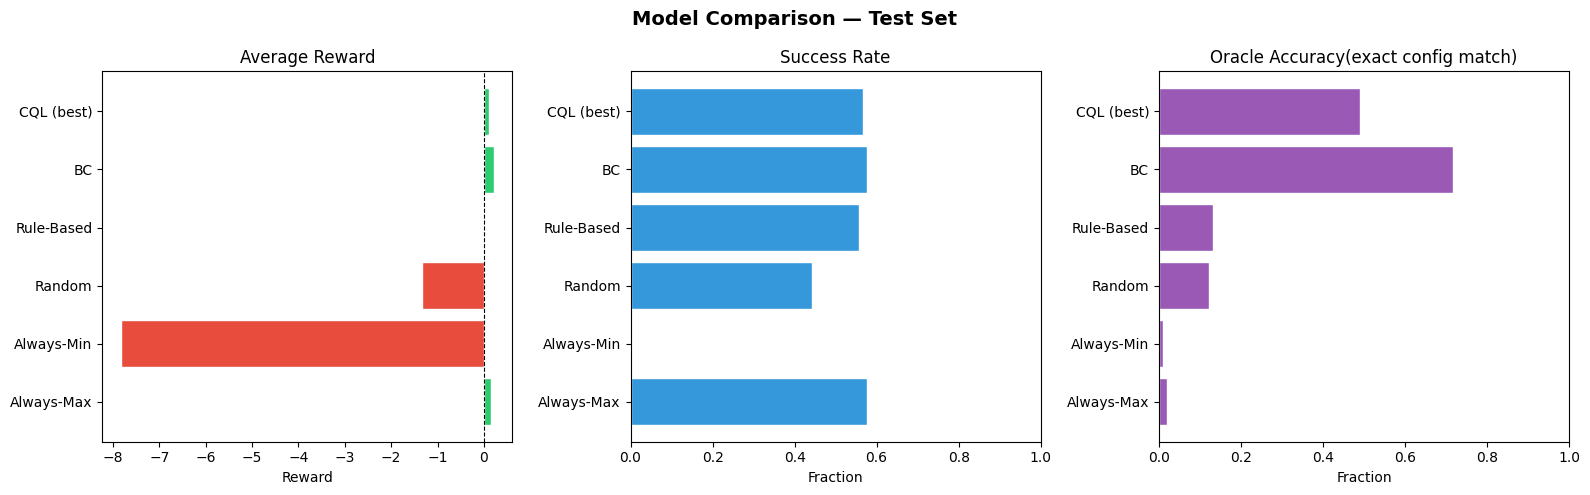

In [18]:
models     = results_df.index.tolist()
colors_bar = ['#e74c3c' if v < 0 else '#2ecc71' for v in results_df['Avg Reward']]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison — Test Set', fontsize=14, fontweight='bold')

axes[0].barh(models, results_df['Avg Reward'], color=colors_bar, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Average Reward')
axes[0].set_xlabel('Reward')

axes[1].barh(models, results_df['Success Rate'], color='#3498db', edgecolor='white')
axes[1].set_title('Success Rate')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Fraction')

axes[2].barh(models, results_df['Oracle Acc'], color='#9b59b6', edgecolor='white')
axes[2].set_title('Oracle Accuracy(exact config match)')
axes[2].set_xlim(0, 1)
axes[2].set_xlabel('Fraction')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

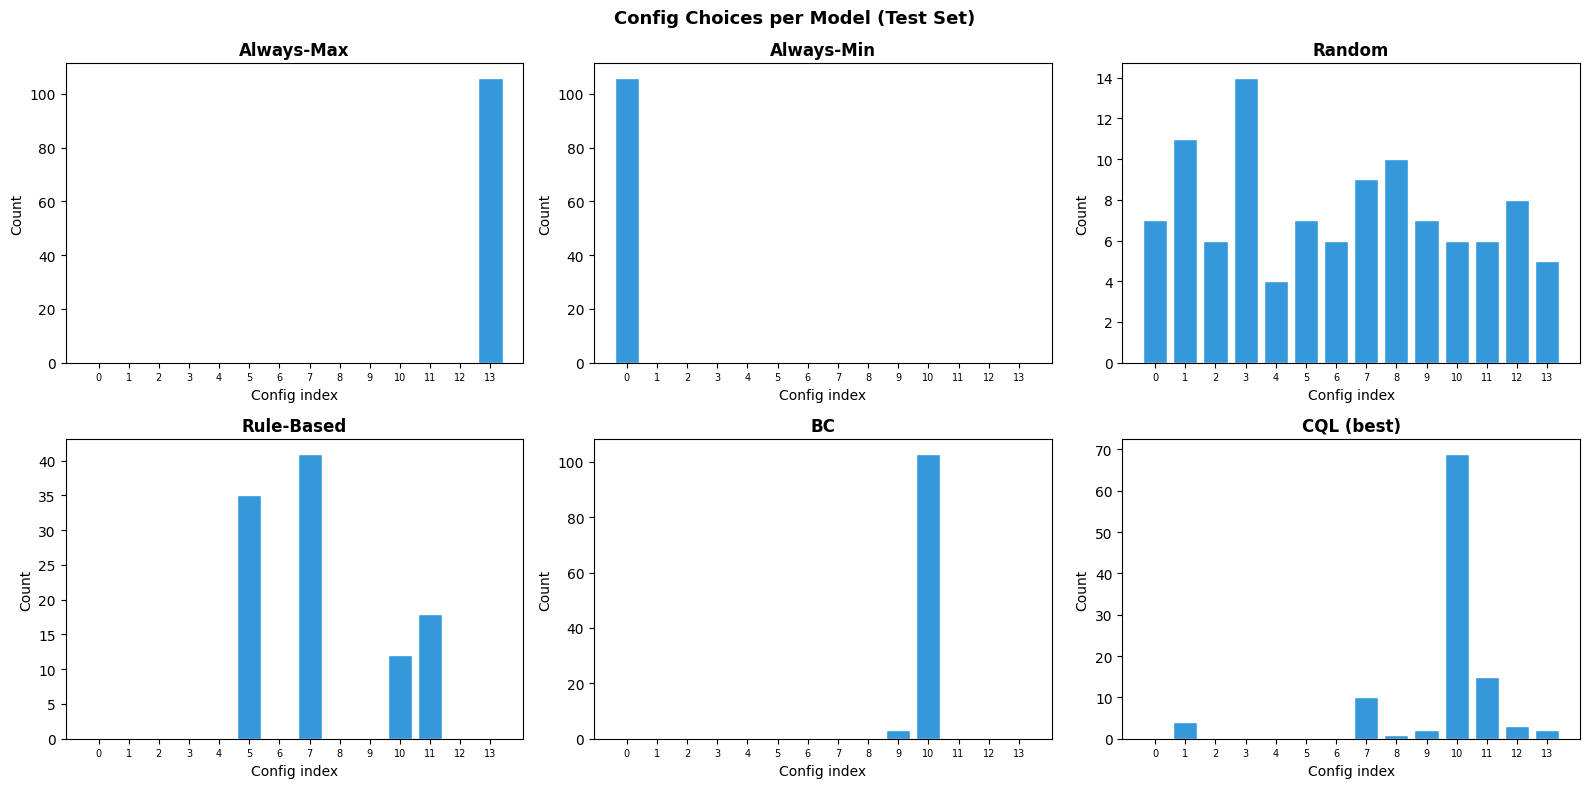

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (name, fn) in enumerate(all_models):
    counts = defaultdict(int)
    for tid, group in df_test.groupby('task_id'):
        s = scaler.transform(group.iloc[0][FEATURE_COLS].values.reshape(1, -1))[0]
        counts[fn(s)] += 1
    vals = [counts.get(j, 0) for j in range(N_ACTIONS)]
    axes[i].bar(range(N_ACTIONS), vals, color='#3498db', edgecolor='white')
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xticks(range(N_ACTIONS))
    axes[i].set_xticklabels([str(j) for j in range(N_ACTIONS)], fontsize=7)
    axes[i].set_xlabel('Config index')
    axes[i].set_ylabel('Count')

plt.suptitle('Config Choices per Model (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('config_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

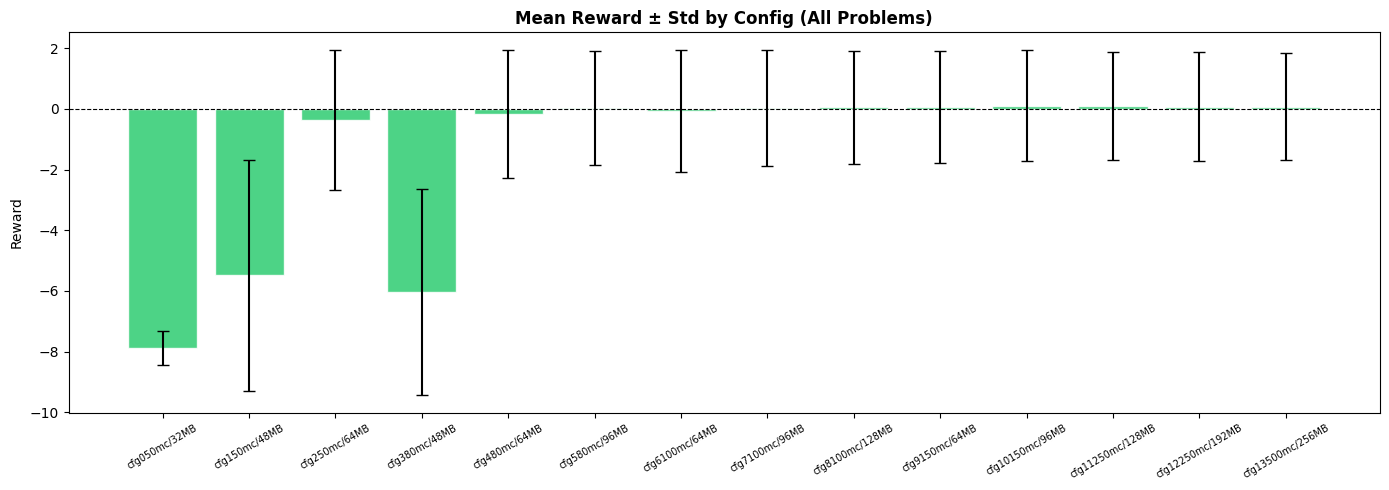

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))
df_grouped = df.groupby('action_idx')['reward'].agg(['mean', 'std']).reset_index()
ax.bar(df_grouped['action_idx'], df_grouped['mean'],
       yerr=df_grouped['std'], capsize=4, color='#2ecc71', edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(range(N_ACTIONS))
ax.set_xticklabels([f"cfg{i}{c['cpu_millicores']}mc/{c['memory_limit_mb']}MB"
                    for i, c in enumerate(ACTION_CONFIGS)], fontsize=7, rotation=30)
ax.set_title('Mean Reward ± Std by Config (All Problems)', fontweight='bold')
ax.set_ylabel('Reward')
plt.tight_layout()
plt.savefig('reward_by_config.png', dpi=150, bbox_inches='tight')
plt.show()

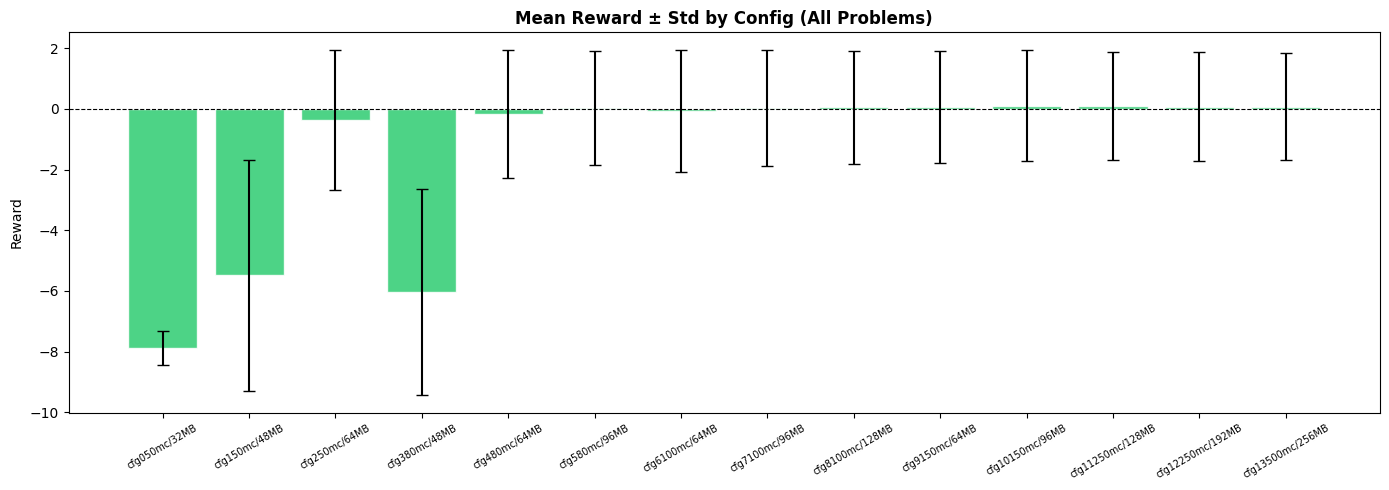

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
df_grouped = df.groupby('action_idx')['reward'].agg(['mean', 'std']).reset_index()
ax.bar(df_grouped['action_idx'], df_grouped['mean'],
       yerr=df_grouped['std'], capsize=4, color='#2ecc71', edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(range(N_ACTIONS))
ax.set_xticklabels([f"cfg{i}{c['cpu_millicores']}mc/{c['memory_limit_mb']}MB"
                    for i, c in enumerate(ACTION_CONFIGS)], fontsize=7, rotation=30)
ax.set_title('Mean Reward ± Std by Config (All Problems)', fontweight='bold')
ax.set_ylabel('Reward')
plt.tight_layout()
plt.savefig('reward_by_config.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
results_df.to_csv('model_results.csv')
print('Saved model_results.csv')
print('Final results:')
print(results_df.sort_values('Avg Reward', ascending=True).round(3).to_string())

Saved model_results.csv
Final results:
            Avg Reward  Success Rate  Oracle Acc  N Problems
model                                                       
Always-Min      -7.831         0.000       0.009         106
Random          -1.338         0.443       0.123         106
Rule-Based       0.018         0.557       0.132         106
CQL (best)       0.111         0.566       0.491         106
Always-Max       0.154         0.575       0.019         106
BC               0.211         0.575       0.717         106
